# Experimentos Univariados 1.1–1.8

**Tesis MEC** — Comparación TSFMs vs Modelos Clásicos bajo DGPs controlados  
**Setup:** T ∈ {200, 1000} | H = 24 | R_LIST = [500] | Semilla = 3649  
**Métricas:** Bias, Varianza, MSE, RMSE, MAE, Cobertura 80%/95%, Amplitud 80%/95%  
**Resultados:** guardados en `results/univariate/` — si existen se cargan sin re-simular

---

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

from mectesis.dgp import AR1, RandomWalk, AR1WithTrend, SeasonalDGP, AR1WithBreak
from mectesis.models import (
    ARIMAModel, ChronosModel,
    SARIMAModel, ARIMAWithTrendModel, ARIMAWithBreakModel,
)
from mectesis.simulation import MonteCarloEngine

# ── Parámetros globales ───────────────────────────────────────────────────
SEED    = 3649
H       = 24
R_LIST  = [500]          # agregar 1000 para robustez: [500, 1000]
T_LIST  = [200, 500]
RESULTS = Path("results/univariate")
RESULTS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
pd.set_option("display.float_format", "{:.4f}".format)

print("Cargando Chronos-2 (puede tardar ~60 s)...")
chronos = ChronosModel(device="cpu")
print("Chronos-2 listo.")

Cargando Chronos-2 (puede tardar ~60 s)...
Chronos-2 listo.


In [2]:
# ─── Funciones auxiliares ───────────────────────────────────────────────────

def _cache_path(exp_id: str, T: int, R: int) -> Path:
    return RESULTS / f"exp_{exp_id.replace('.', '_')}_T{T}_R{R}.csv"


def _save_results(results: dict, path: Path):
    """Guarda {model_name: DataFrame} como CSV con columna 'model'."""
    frames = []
    for mname, df in results.items():
        tmp = df.copy()
        tmp.insert(0, 'model', mname)
        frames.append(tmp)
    pd.concat(frames, ignore_index=True).to_csv(path, index=False)


def _load_results(path: Path) -> dict:
    """Carga CSV de vuelta a {model_name: DataFrame}."""
    df = pd.read_csv(path)
    return {
        mname: grp.drop(columns='model').reset_index(drop=True)
        for mname, grp in df.groupby('model', sort=False)
    }


def run_exp(dgp, make_models_fn, dgp_params, exp_id,
            T_list=T_LIST, R_list=R_LIST, H=H, seed=SEED):
    """
    Corre MC para todas las combinaciones (T, R).
    Si el CSV ya existe, lo carga sin re-simular.
    Retorna {(T, R): {model_name: DataFrame}}.
    """
    n_runs = len(T_list) * len(R_list)
    combos = ', '.join(f'(T={t}, R={r})' for t in T_list for r in R_list)
    print(f'Exp {exp_id}: {n_runs} ejecución(es) programada(s) → {combos}')

    all_results = {}
    for T in T_list:
        for R in R_list:
            cache = _cache_path(exp_id, T, R)
            if cache.exists():
                print(f'  T={T}, R={R}: cargando {cache.name} ...')
                all_results[(T, R)] = _load_results(cache)
                continue

            print(f'  T={T}, R={R}: simulando ...', end=' ', flush=True)
            dgp.rng = np.random.default_rng(seed)
            models = make_models_fn(T)
            engine = MonteCarloEngine(dgp, models, seed=seed)
            t0 = time.time()
            results = engine.run_monte_carlo(
                R, T, H, dgp_params, verbose=False)
            elapsed = time.time() - t0
            print(f'OK ({elapsed:.0f}s)')

            _save_results(results, cache)
            all_results[(T, R)] = results

    return all_results   # {(T, R): {model_name: DataFrame}}


def compute_blocks(results_TR: dict):
    """Dado {model_name: df}, calcula promedios h=1-12 y h=13-24."""
    out = {}
    for mname, df in results_TR.items():
        df_h = df[df["horizon"] != "avg_all"].copy()
        df_h["horizon"] = pd.to_numeric(df_h["horizon"], errors="coerce")
        out[mname] = {
            "h=1-12":  df_h[df_h["horizon"] <= 12].mean(numeric_only=True),
            "h=13-24": df_h[df_h["horizon"] >= 13].mean(numeric_only=True),
        }
    return out


def results_table(all_results):
    """Muestra tabla comparativa de métricas por bloque para todos los (T, R)."""
    # Detect available metric columns from first DataFrame
    sample_df = next(iter(next(iter(all_results.values())).values()))
    numeric_cols = [c for c in sample_df.columns
                    if c not in ('horizon',) and sample_df[c].dtype != object]

    rows = []
    for (T, R), res_TR in sorted(all_results.items()):
        for mname, blk in compute_blocks(res_TR).items():
            for bname, m in blk.items():
                row = {'T': T, 'R': R, 'Modelo': mname, 'Bloque': bname}
                for col in numeric_cols:
                    if col in m.index:
                        row[col] = round(float(m[col]), 4)
                rows.append(row)

    df = pd.DataFrame(rows).set_index(['T', 'R', 'Modelo', 'Bloque'])
    grad_cols = [c for c in ['rmse', 'mae'] if c in df.columns]
    display(df.style.format(precision=4)
              .background_gradient(subset=grad_cols, cmap='YlOrRd'))


def plot_rep(dgp, make_models_fn, dgp_params,
             T=200, H=H, seed=SEED, title=''):
    """Visualización de una simulación representativa."""
    dgp_r = dgp.__class__(seed=seed)
    y = dgp_r.simulate(T=T, **dgp_params)
    y_train, y_test = y[:-H], y[-H:]
    models = make_models_fn(T)

    fig, ax = plt.subplots(figsize=(13, 4))
    x_tr = np.arange(len(y_train))
    x_te = np.arange(len(y_train), T)

    ax.plot(x_tr, y_train, color="steelblue", lw=1.4, alpha=0.85, label="Histórico")
    ax.plot(x_te, y_test, "k--", lw=1.5, label="Observado (test)")
    ax.axvline(len(y_train) - 0.5, color='gray', ls=':', lw=1, alpha=0.6)

    palette = ['crimson', 'darkorange', 'seagreen', 'purple', 'teal', 'olive']
    for i, m in enumerate(models):
        m.fit(y_train)
        y_hat = m.forecast(H)
        ax.plot(x_te, y_hat, color=palette[i % len(palette)],
                lw=1.5, marker='o', ms=3, label=m.name)
        if m.supports_intervals:
            lo, hi = m.forecast_intervals(H, level=0.95)
            ax.fill_between(x_te, lo, hi,
                            color=palette[i % len(palette)],
                            alpha=0.12, label='_nolegend_')

    ax.set(title=title, xlabel='t', ylabel='$Y_t$')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_metrics(all_results, title='', metrics=('rmse', 'bias')):
    """Gráficos de métricas vs h=1..24 por modelo, subplots por (T, R)."""
    keys = sorted(all_results.keys())
    fig, axes = plt.subplots(
        len(metrics), len(keys),
        figsize=(7 * len(keys), 3.5 * len(metrics)),
        squeeze=False,
    )
    palette = ['crimson', 'darkorange', 'seagreen', 'purple', 'teal', 'steelblue']

    for col, (T, R) in enumerate(keys):
        for row, metric in enumerate(metrics):
            ax = axes[row][col]
            for i, (mname, df) in enumerate(all_results[(T, R)].items()):
                df_h = df[df["horizon"] != "avg_all"].copy()
                df_h["horizon"] = pd.to_numeric(df_h["horizon"], errors="coerce")
                if metric not in df_h.columns:
                    continue
                ax.plot(df_h['horizon'], df_h[metric],
                        label=mname, color=palette[i % len(palette)], lw=1.5)
            ax.axvline(12.5, color='gray', ls=':', lw=0.8, alpha=0.5)
            ax.set(
                title=f'T={T}, R={R} — {metric.upper()}',
                xlabel='Horizonte h',
                ylabel=metric.upper(),
            )
            ax.legend(fontsize=8)

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

---
## Experimento 1.1

**DGP:** AR(1) baja persistencia — $Y_t = 0.3\,Y_{t-1} + \varepsilon_t$  
**Core:** ARIMA(1,0,0), Chronos-2  
**Adicionales (no implementados aquí):** ETS(A,N,N), Theta, Naive, Drift

In [3]:
dgp_1_1         = AR1(seed=SEED)
make_models_1_1 = lambda T: [ARIMAModel((1,0,0)), chronos]
dgp_params_1_1  = {'phi': 0.3}

results_1_1 = run_exp(
    dgp_1_1, make_models_1_1, dgp_params_1_1,
    exp_id='1.1',
)

Exp 1.1: 2 ejecución(es) programada(s) → (T=200, R=500), (T=500, R=500)
  T=200, R=500: simulando ... OK (278s)
  T=500, R=500: simulando ... OK (421s)


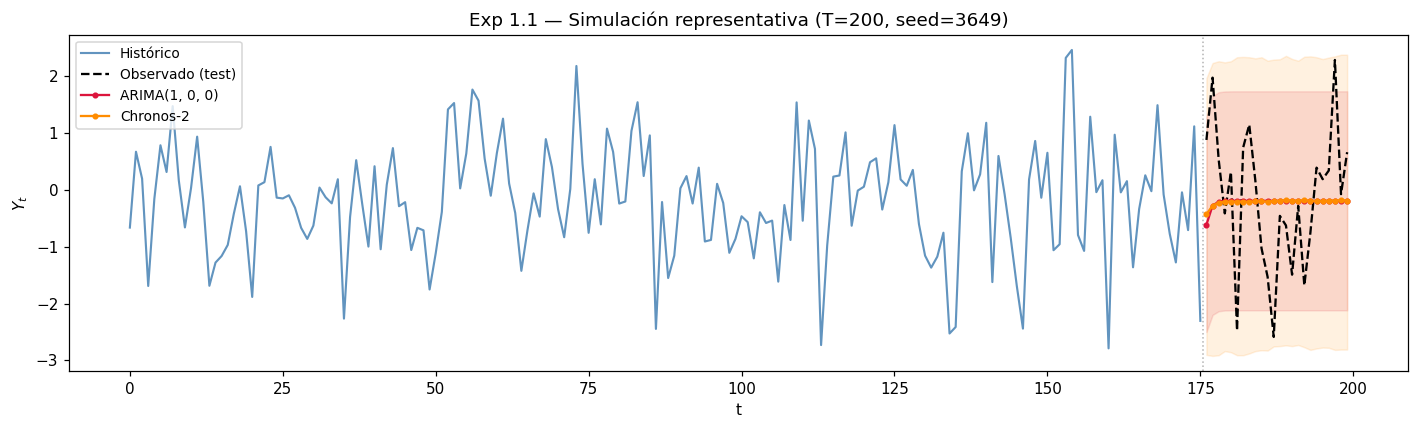

Tabla de métricas — Exp 1.1


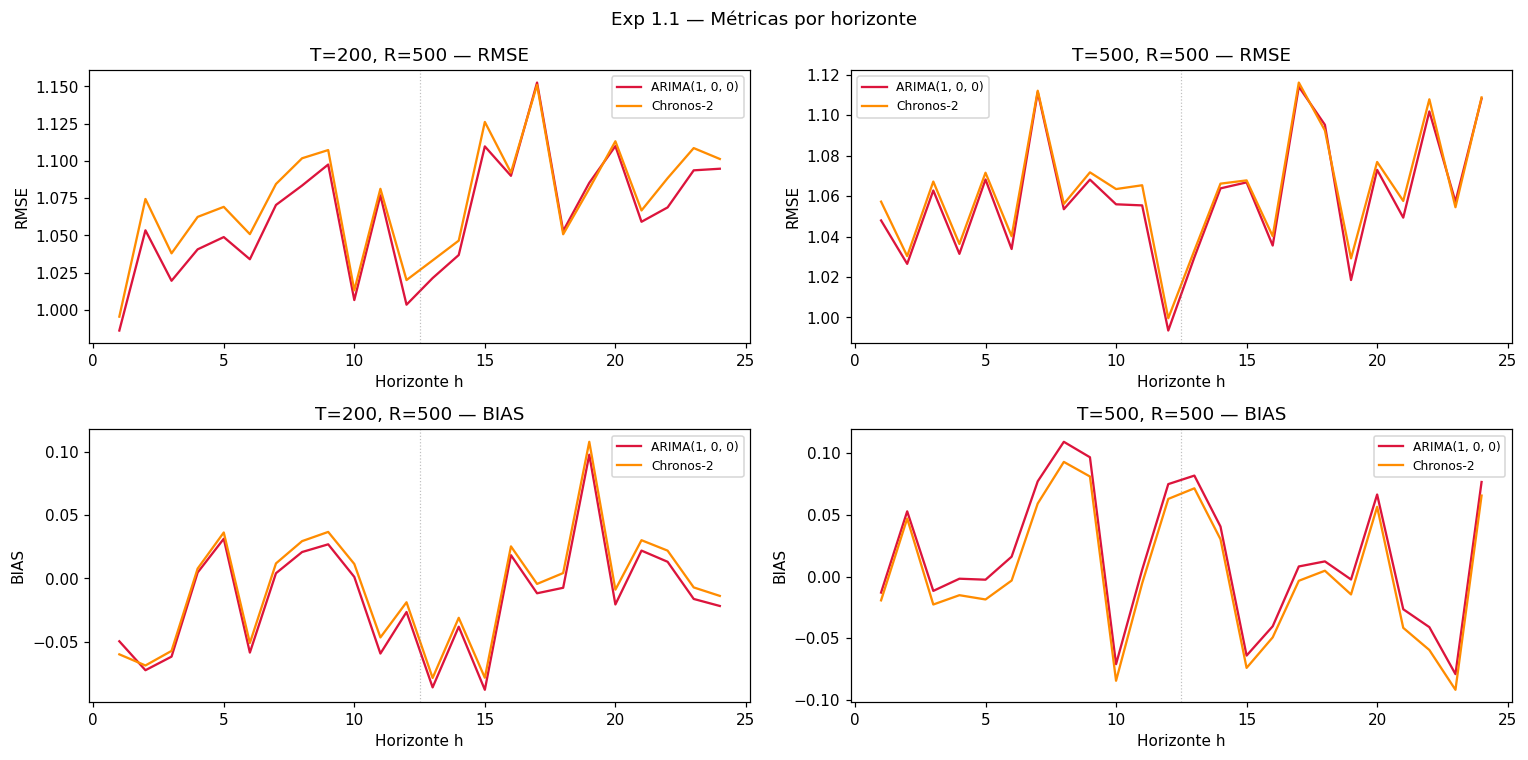

In [4]:
# Visualización representativa con banda de intervalo 95% (T=200)
plot_rep(
    dgp_1_1, make_models_1_1, dgp_params_1_1,
    T=200, title=f"Exp 1.1 — Simulación representativa (T=200, seed={SEED})"
)

# Tabla de métricas por bloque
print("Tabla de métricas — Exp 1.1")
results_table(results_1_1)

# Gráficos de métricas por horizonte
plot_metrics(
    results_1_1,
    title=f"Exp 1.1 — Métricas por horizonte"
)

---
## Experimento 1.2

**DGP:** AR(1) alta persistencia — $Y_t = 0.9\,Y_{t-1} + \varepsilon_t$  
**Core:** ARIMA(1,0,0), Chronos-2  
**Adicionales:** ETS(A,A,N), Theta, Naive

In [5]:
dgp_1_2         = AR1(seed=SEED)
make_models_1_2 = lambda T: [ARIMAModel((1,0,0)), chronos]
dgp_params_1_2  = {'phi': 0.9}

results_1_2 = run_exp(
    dgp_1_2, make_models_1_2, dgp_params_1_2,
    exp_id='1.2',
)

Exp 1.2: 2 ejecución(es) programada(s) → (T=200, R=500), (T=500, R=500)
  T=200, R=500: simulando ... OK (287s)
  T=500, R=500: simulando ... OK (494s)


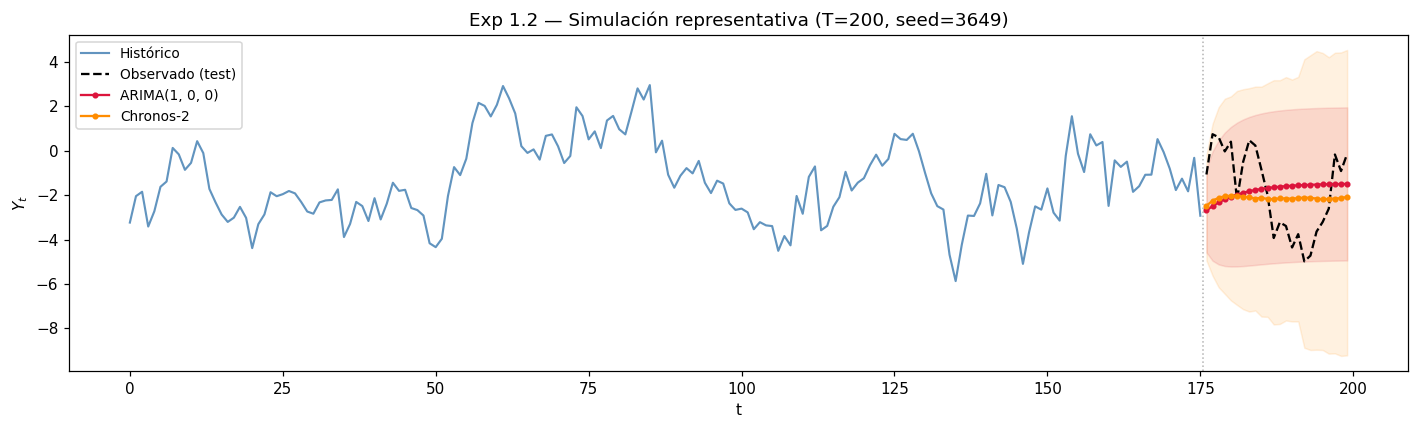

Tabla de métricas — Exp 1.2


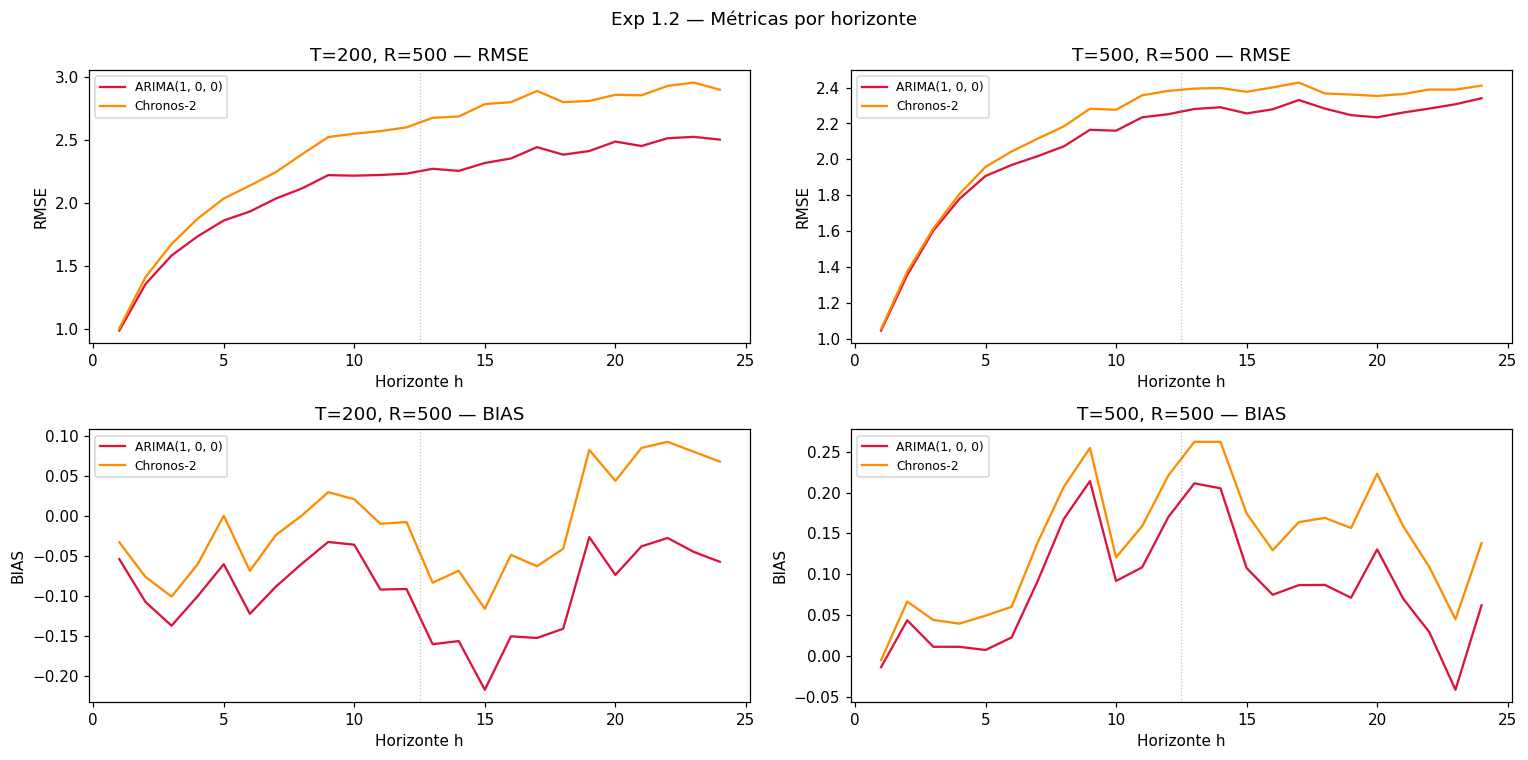

In [6]:
# Visualización representativa con banda de intervalo 95% (T=200)
plot_rep(
    dgp_1_2, make_models_1_2, dgp_params_1_2,
    T=200, title=f"Exp 1.2 — Simulación representativa (T=200, seed={SEED})"
)

# Tabla de métricas por bloque
print("Tabla de métricas — Exp 1.2")
results_table(results_1_2)

# Gráficos de métricas por horizonte
plot_metrics(
    results_1_2,
    title=f"Exp 1.2 — Métricas por horizonte"
)

---
## Experimento 1.3

**DGP:** Random Walk I(1) sin drift — $Y_t = Y_{t-1} + \varepsilon_t$  
**Core:** ARIMA(0,1,0), Chronos-2  
**Adicionales:** ETS(A,A,N), Theta, Drift

In [7]:
dgp_1_3         = RandomWalk(seed=SEED)
make_models_1_3 = lambda T: [ARIMAModel((0,1,0)), chronos]
dgp_params_1_3  = {'drift': 0.0}

results_1_3 = run_exp(
    dgp_1_3, make_models_1_3, dgp_params_1_3,
    exp_id='1.3',
)

Exp 1.3: 2 ejecución(es) programada(s) → (T=200, R=500), (T=500, R=500)
  T=200, R=500: simulando ... OK (250s)
  T=500, R=500: simulando ... OK (357s)


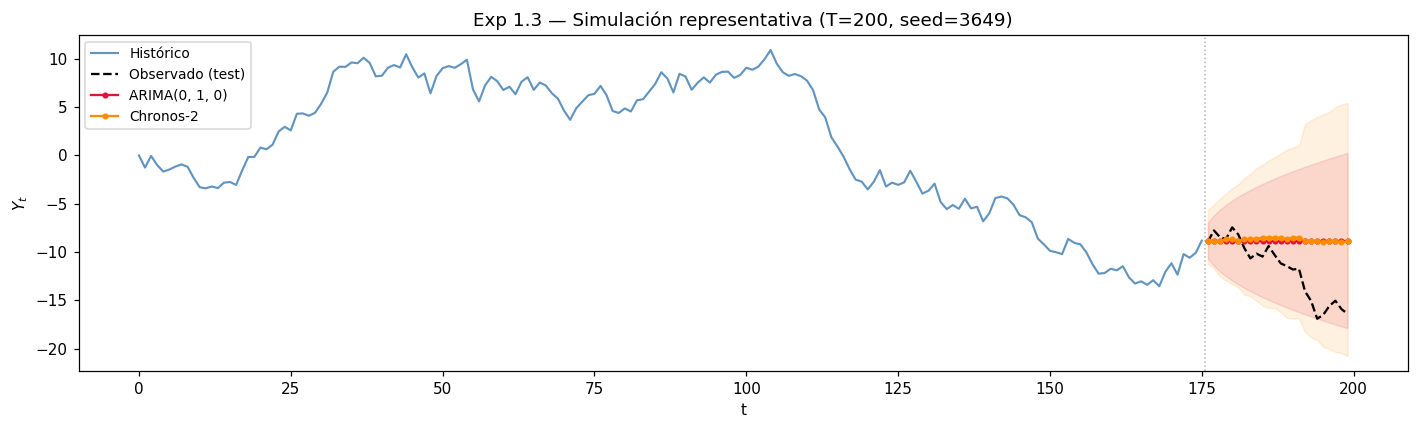

Tabla de métricas — Exp 1.3


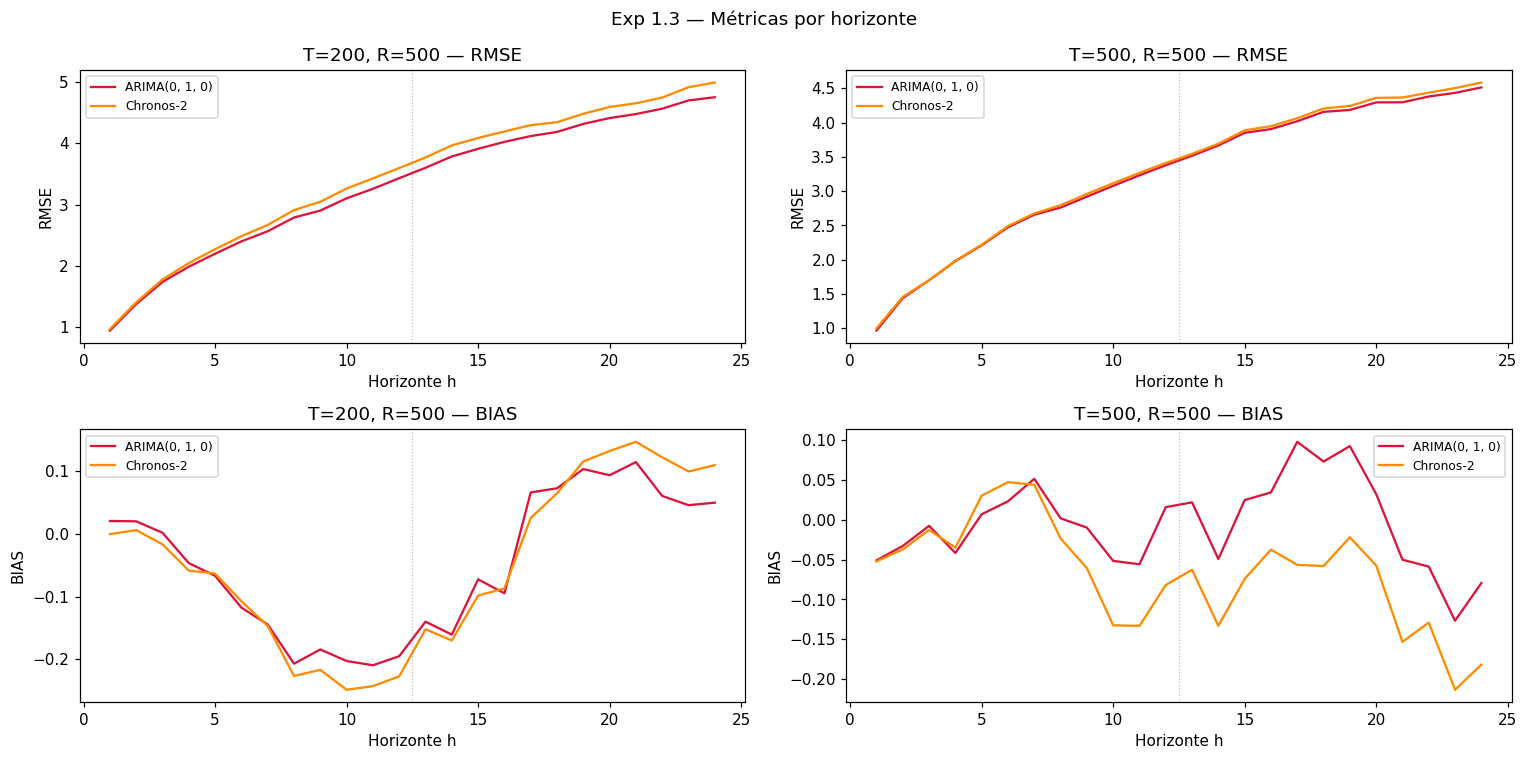

In [8]:
# Visualización representativa con banda de intervalo 95% (T=200)
plot_rep(
    dgp_1_3, make_models_1_3, dgp_params_1_3,
    T=200, title=f"Exp 1.3 — Simulación representativa (T=200, seed={SEED})"
)

# Tabla de métricas por bloque
print("Tabla de métricas — Exp 1.3")
results_table(results_1_3)

# Gráficos de métricas por horizonte
plot_metrics(
    results_1_3,
    title=f"Exp 1.3 — Métricas por horizonte"
)

---
## Experimento 1.4

**DGP:** Random Walk I(1) con drift — $Y_t = 0.5 + Y_{t-1} + \varepsilon_t$  
**Core:** ARIMA(0,1,0), Chronos-2  
**Adicionales:** ETS(A,A,N), Theta, Drift

In [9]:
dgp_1_4         = RandomWalk(seed=SEED)
make_models_1_4 = lambda T: [ARIMAModel((0,1,0)), chronos]
dgp_params_1_4  = {'drift': 0.5}

results_1_4 = run_exp(
    dgp_1_4, make_models_1_4, dgp_params_1_4,
    exp_id='1.4',
)

Exp 1.4: 2 ejecución(es) programada(s) → (T=200, R=500), (T=500, R=500)
  T=200, R=500: simulando ... OK (236s)
  T=500, R=500: simulando ... OK (349s)


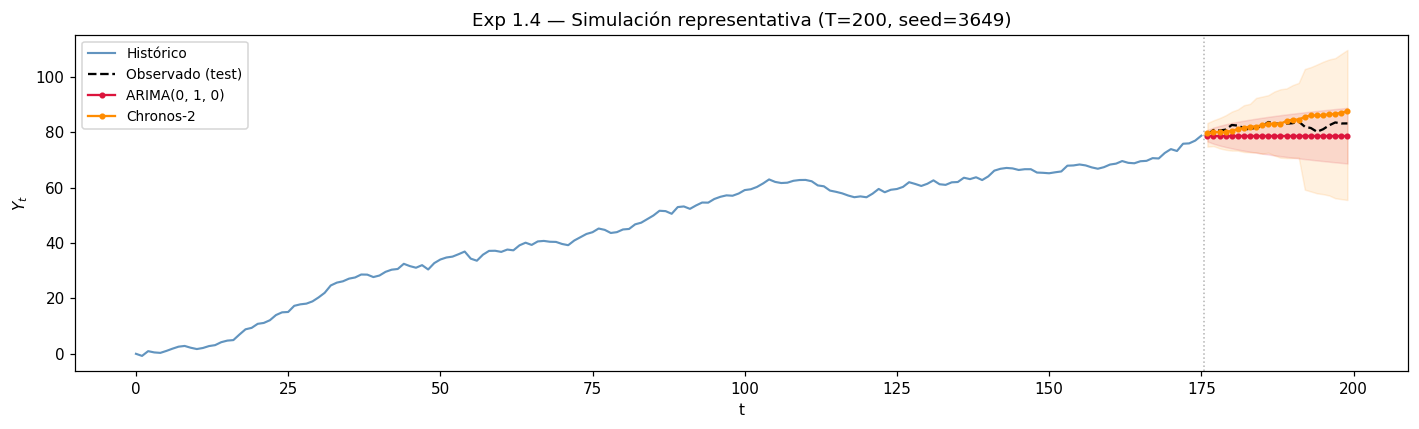

Tabla de métricas — Exp 1.4


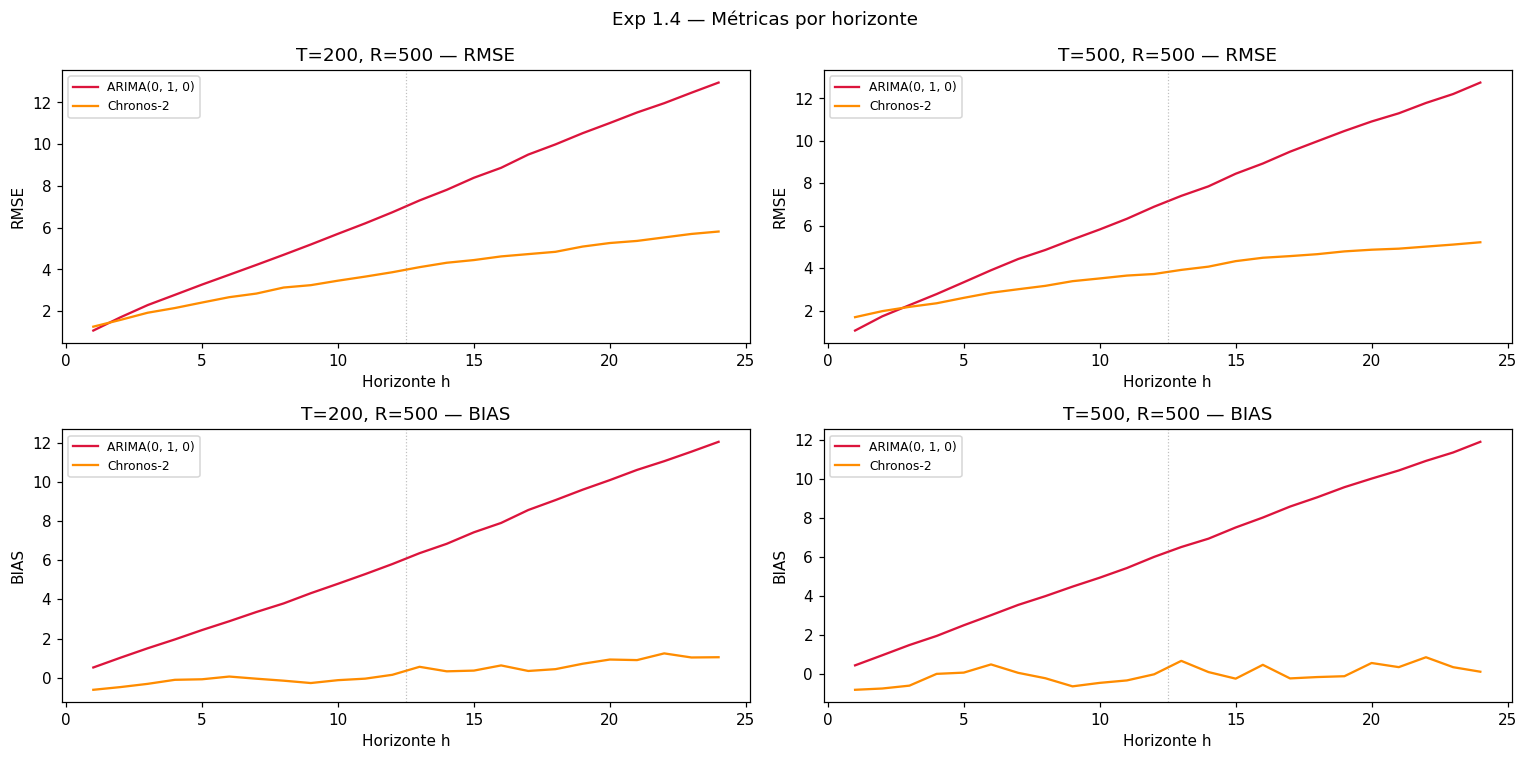

In [10]:
# Visualización representativa con banda de intervalo 95% (T=200)
plot_rep(
    dgp_1_4, make_models_1_4, dgp_params_1_4,
    T=200, title=f"Exp 1.4 — Simulación representativa (T=200, seed={SEED})"
)

# Tabla de métricas por bloque
print("Tabla de métricas — Exp 1.4")
results_table(results_1_4)

# Gráficos de métricas por horizonte
plot_metrics(
    results_1_4,
    title=f"Exp 1.4 — Métricas por horizonte"
)

---
## Experimento 1.5

**DGP:** AR(1) + tendencia — $Y_t = 5 + 0.1t + 0.6\,Y_{t-1} + \varepsilon_t$  
**Core:** ARIMA(1,0,0)+trend (trend='ct'), Chronos-2  
**Adicionales:** Holt-Winters, ETS, Theta

In [11]:
dgp_1_5         = AR1WithTrend(seed=SEED)
make_models_1_5 = lambda T: [ARIMAWithTrendModel((1,0,0), trend='ct'), chronos]
dgp_params_1_5  = {'intercept': 5.0, 'trend_coeff': 0.1, 'phi': 0.6}

results_1_5 = run_exp(
    dgp_1_5, make_models_1_5, dgp_params_1_5,
    exp_id='1.5',
)

Exp 1.5: 2 ejecución(es) programada(s) → (T=200, R=500), (T=500, R=500)
  T=200, R=500: simulando ... OK (316s)
  T=500, R=500: simulando ... OK (481s)


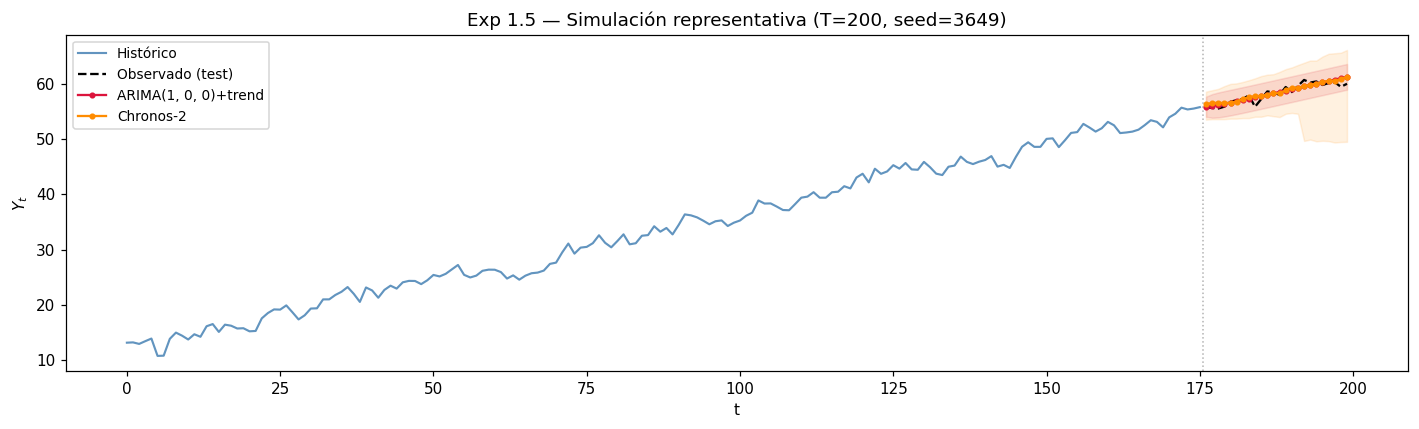

Tabla de métricas — Exp 1.5


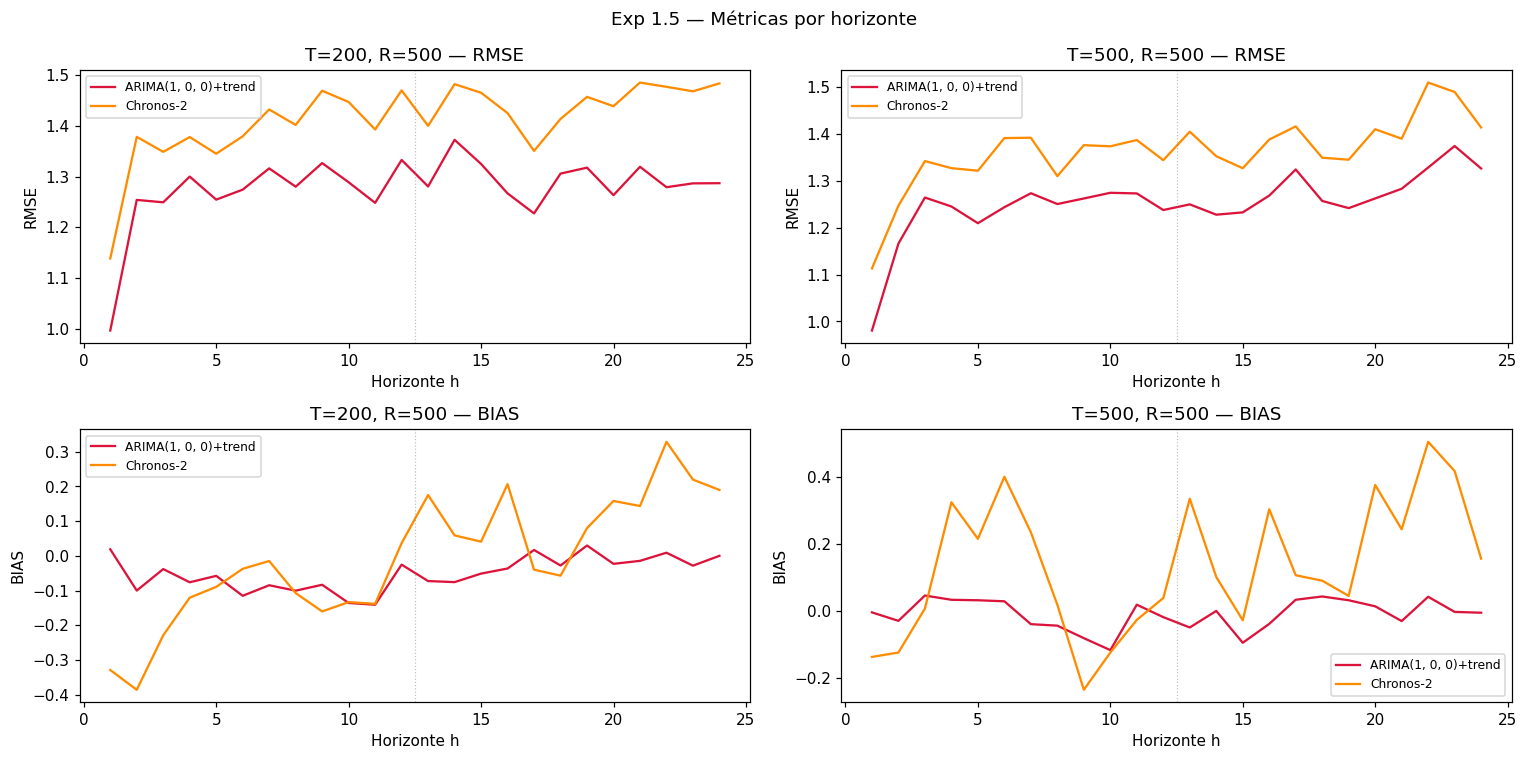

In [12]:
# Visualización representativa con banda de intervalo 95% (T=200)
plot_rep(
    dgp_1_5, make_models_1_5, dgp_params_1_5,
    T=200, title=f"Exp 1.5 — Simulación representativa (T=200, seed={SEED})"
)

# Tabla de métricas por bloque
print("Tabla de métricas — Exp 1.5")
results_table(results_1_5)

# Gráficos de métricas por horizonte
plot_metrics(
    results_1_5,
    title=f"Exp 1.5 — Métricas por horizonte"
)

---
## Experimento 1.6

**DGP:** SARIMA trimestral (s=4) — $(1-0.5L)(1-0.3L^4)Y_t = \varepsilon_t$  
**Core:** SARIMA(1,0,0)(1,0,0)_4, Chronos-2  
**Adicionales:** ETS(A,A,A), Seasonal Naive

In [13]:
dgp_1_6         = SeasonalDGP(seed=SEED)
make_models_1_6 = lambda T: [SARIMAModel((1,0,0),(1,0,0,4)), chronos]
dgp_params_1_6  = {'phi': 0.5, 'Phi': 0.3, 's': 4, 'integrated': False}

results_1_6 = run_exp(
    dgp_1_6, make_models_1_6, dgp_params_1_6,
    exp_id='1.6',
)

Exp 1.6: 2 ejecución(es) programada(s) → (T=200, R=500), (T=500, R=500)
  T=200, R=500: simulando ... OK (216s)
  T=500, R=500: simulando ... OK (463s)


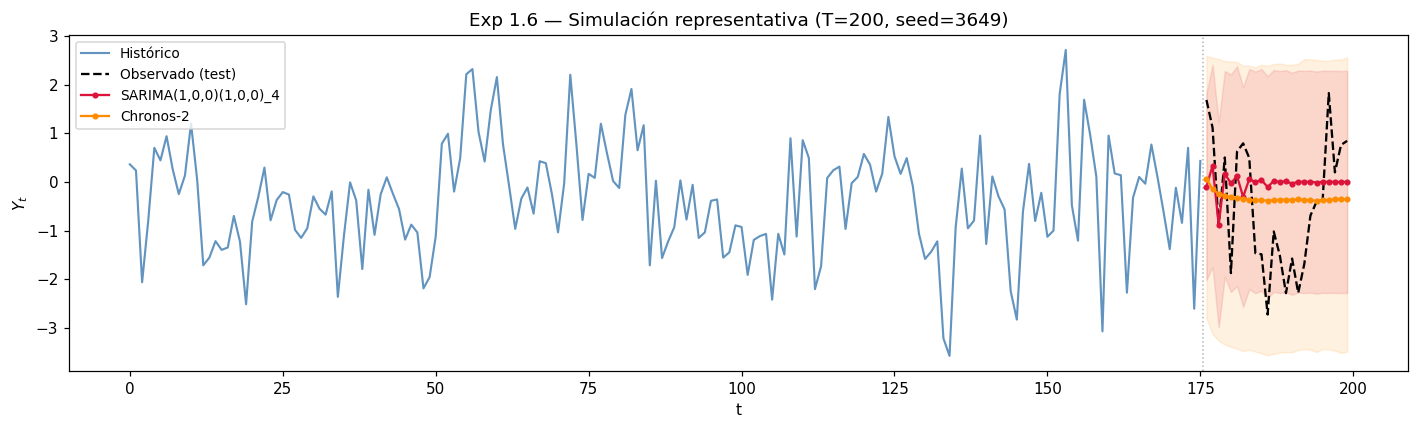

Tabla de métricas — Exp 1.6


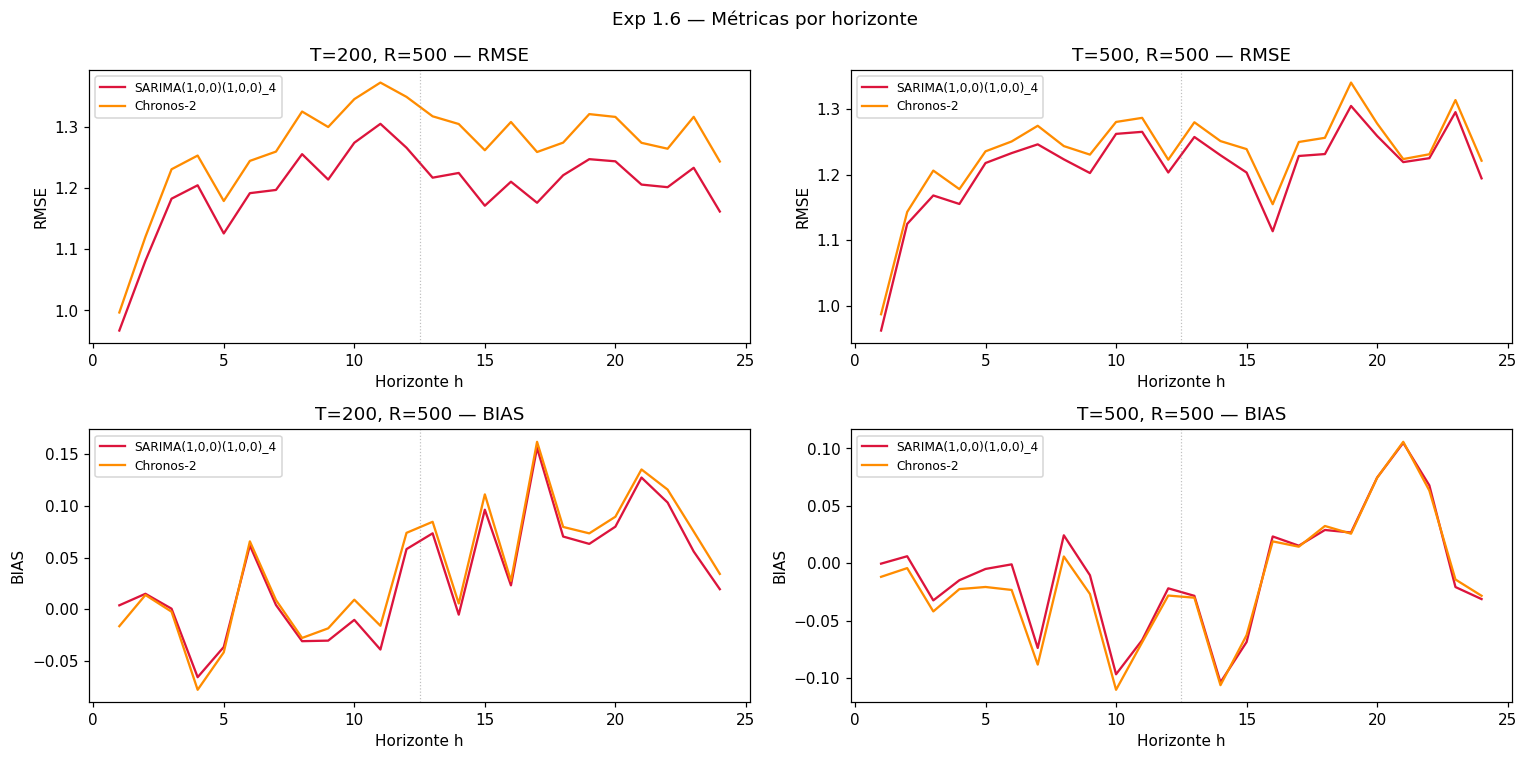

In [14]:
# Visualización representativa con banda de intervalo 95% (T=200)
plot_rep(
    dgp_1_6, make_models_1_6, dgp_params_1_6,
    T=200, title=f"Exp 1.6 — Simulación representativa (T=200, seed={SEED})"
)

# Tabla de métricas por bloque
print("Tabla de métricas — Exp 1.6")
results_table(results_1_6)

# Gráficos de métricas por horizonte
plot_metrics(
    results_1_6,
    title=f"Exp 1.6 — Métricas por horizonte"
)

---
## Experimento 1.7

**DGP:** SARIMA mensual (s=12) — $(1-L)(1-L^{12})Y_t = \varepsilon_t$  
**Core:** SARIMA(0,1,0)(0,1,0)_12, Chronos-2  
**Adicionales:** Holt-Winters multiplicativo, ETS, Seasonal Naive

In [15]:
dgp_1_7         = SeasonalDGP(seed=SEED)
make_models_1_7 = lambda T: [SARIMAModel((0,1,0),(0,1,0,12)), chronos]
dgp_params_1_7  = {'integrated': True, 's': 12}

results_1_7 = run_exp(
    dgp_1_7, make_models_1_7, dgp_params_1_7,
    exp_id='1.7',
)

Exp 1.7: 2 ejecución(es) programada(s) → (T=200, R=500), (T=500, R=500)
  T=200, R=500: simulando ... OK (260s)
  T=500, R=500: simulando ... OK (438s)


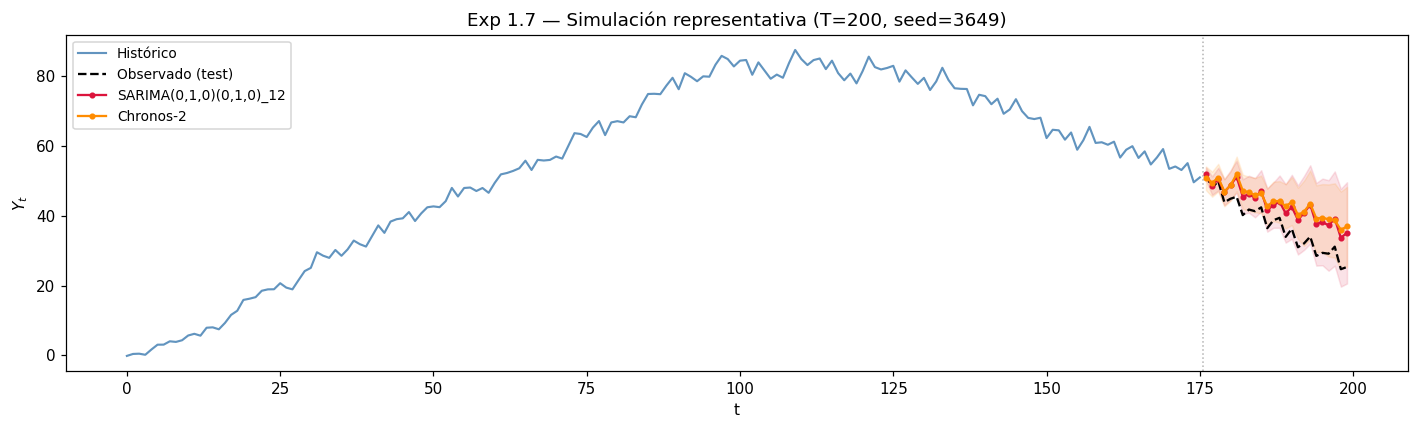

Tabla de métricas — Exp 1.7


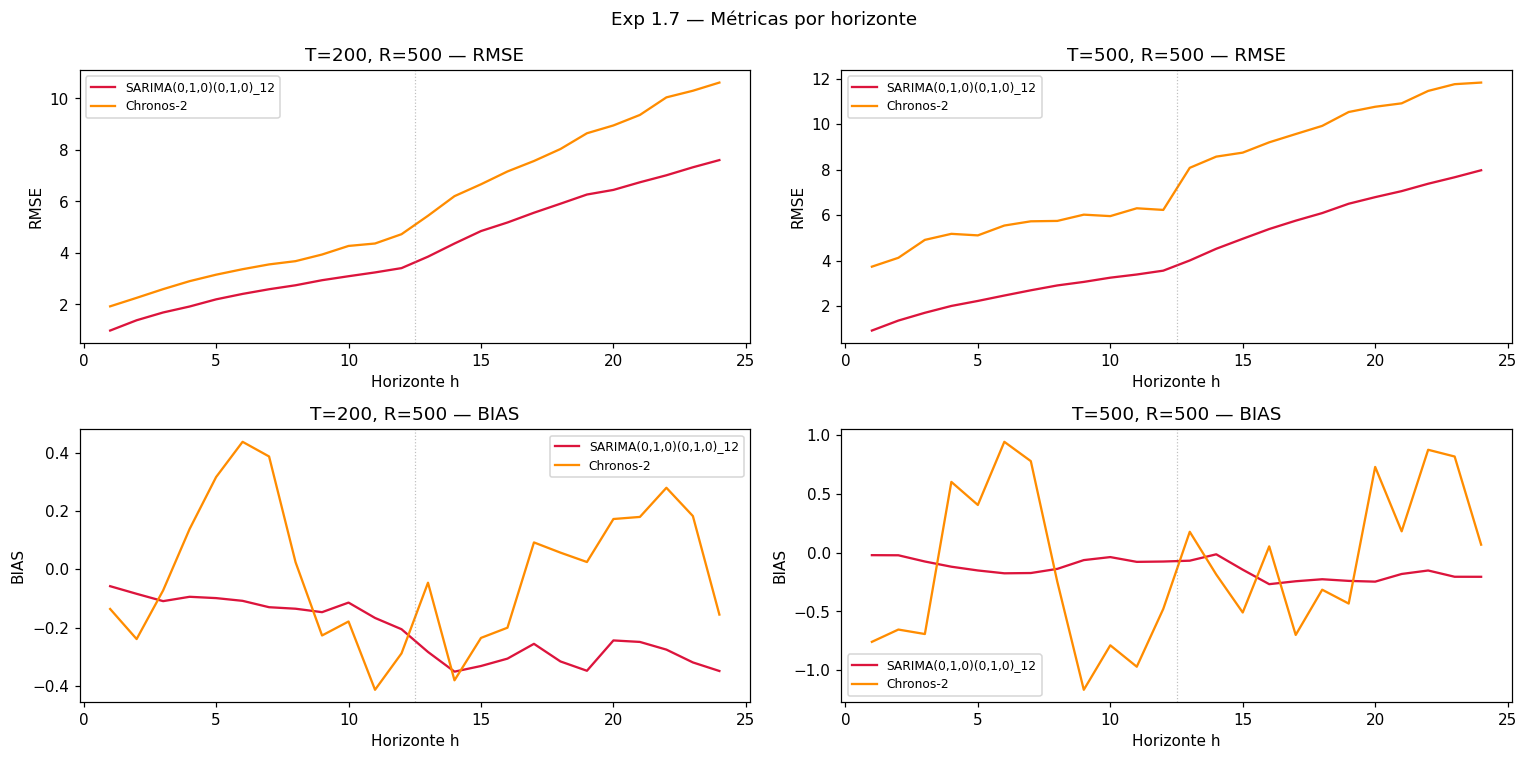

In [16]:
# Visualización representativa con banda de intervalo 95% (T=200)
plot_rep(
    dgp_1_7, make_models_1_7, dgp_params_1_7,
    T=200, title=f"Exp 1.7 — Simulación representativa (T=200, seed={SEED})"
)

# Tabla de métricas por bloque
print("Tabla de métricas — Exp 1.7")
results_table(results_1_7)

# Gráficos de métricas por horizonte
plot_metrics(
    results_1_7,
    title=f"Exp 1.7 — Métricas por horizonte"
)

---
## Experimento 1.8

**DGP:** AR(1) con quiebre en $T/2$ — $\phi$ cambia de 0.3 a 0.8  
**Core:** ARIMA(1,0,0)+break (dummy exógena), Chronos-2  
**Adicionales:** ARIMA(1,0,0) sin quiebre, ETS

In [17]:
dgp_1_8         = AR1WithBreak(seed=SEED)
make_models_1_8 = lambda T: [ARIMAWithBreakModel((1,0,0), T_total=T), chronos]
dgp_params_1_8  = {'phi_before': 0.3, 'phi_after': 0.8}

results_1_8 = run_exp(
    dgp_1_8, make_models_1_8, dgp_params_1_8,
    exp_id='1.8',
)

Exp 1.8: 2 ejecución(es) programada(s) → (T=200, R=500), (T=500, R=500)
  T=200, R=500: simulando ... OK (294s)
  T=500, R=500: simulando ... OK (455s)


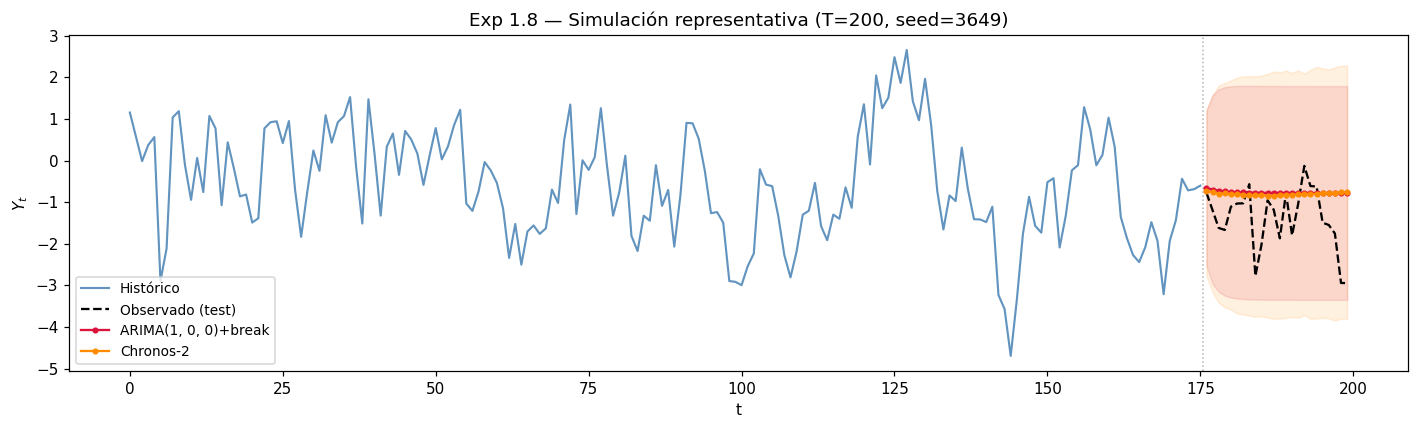

Tabla de métricas — Exp 1.8


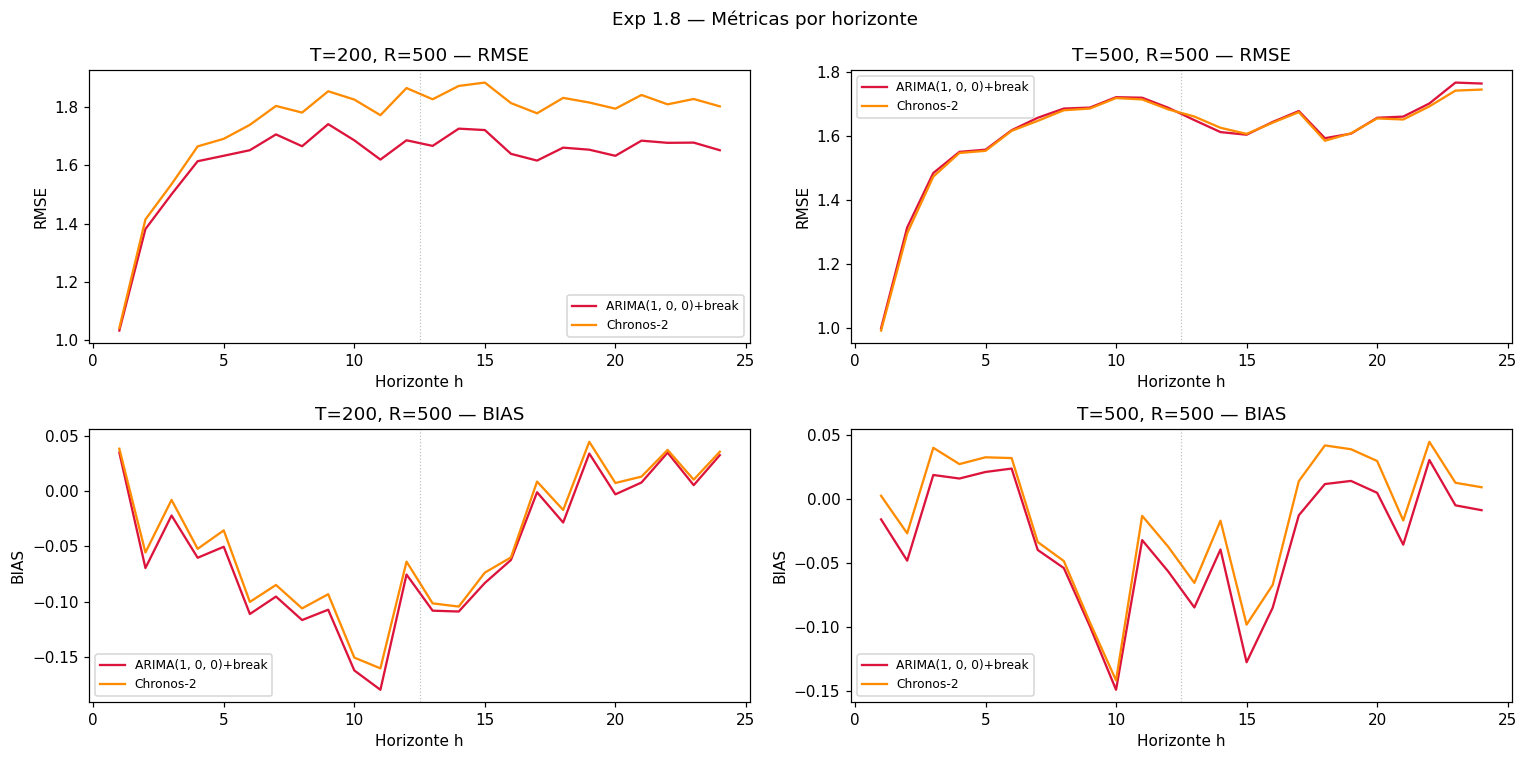

In [18]:
# Visualización representativa con banda de intervalo 95% (T=200)
plot_rep(
    dgp_1_8, make_models_1_8, dgp_params_1_8,
    T=200, title=f"Exp 1.8 — Simulación representativa (T=200, seed={SEED})"
)

# Tabla de métricas por bloque
print("Tabla de métricas — Exp 1.8")
results_table(results_1_8)

# Gráficos de métricas por horizonte
plot_metrics(
    results_1_8,
    title=f"Exp 1.8 — Métricas por horizonte"
)